In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("cleaned1_covid-19_cases_canada.csv")

print(data.head())
print("Number of records:", len(data))

   provincial_case_id    age     sex      health_region province country  \
0                   1  50-59    Male            Toronto  Ontario  Canada   
1                   2  50-59  Female            Toronto  Ontario  Canada   
2                   1  40-49    Male  Vancouver Coastal       BC  Canada   
3                   3  20-29  Female   Middlesex-London  Ontario  Canada   
4                   2  50-59  Female  Vancouver Coastal       BC  Canada   

  date_report report_week has_travel_history locally_acquired  \
0  25-01-2020  19-01-2020                Yes          Unknown   
1  27-01-2020  26-01-2020                Yes          Unknown   
2  28-01-2020  26-01-2020                Yes          Unknown   
3  31-01-2020  26-01-2020                Yes          Unknown   
4  04-02-2020  02-02-2020                 No    Close Contact   

                                         case_source  
0  (1) https://news.ontario.ca/mohltc/en/2020/01/...  
1  (1) https://news.ontario.ca/mohltc/en/2

In [4]:
# i.)
data["date_report"] = pd.to_datetime(
    data["date_report"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [5]:
print(data["date_report"].head())

0   2020-01-25
1   2020-01-27
2   2020-01-28
3   2020-01-31
4   2020-02-04
Name: date_report, dtype: datetime64[ns]


In [6]:
data["Month"] = data["date_report"].dt.to_period("M").astype(str)

In [7]:
gender_month = (
    data[data["sex"].isin(["Male", "Female"])]
    .groupby(["Month", "sex"])
    .size()
    .reset_index(name="Total Cases")
    .sort_values(["Month", "sex"])
)

In [8]:
print(gender_month)

     Month     sex  Total Cases
0  2020-01  Female            2
1  2020-01    Male            2
2  2020-02  Female           10
3  2020-02    Male            6
4  2020-03  Female          416
5  2020-03    Male          425
6  2020-04  Female          247
7  2020-04    Male          192


In [9]:
# ii.)
female_age = (
    data[data["sex"] == "Female"]
    .groupby("age")
    .size()
    .reset_index(name="Female Cases")
    .sort_values("Female Cases", ascending=False)
)

In [10]:
display(female_age)

,age,Female Cases
4,50-59,145
5,60-69,106
2,30-39,105
1,20-29,88
3,40-49,84
6,70-79,68
7,80-89,29
8,90-99,28
0,0-19,17
9,Oct-19,5


In [11]:
#iii.)
older_than_50 = [
    "50-59",
    "60-69",
    "70-79",
    "80-89",
    "90-99"
]

In [12]:
top_two_months = (
    data[
        (data["has_travel_history"] == "No") &
        (data["age"].isin(older_than_50))
    ]
    .groupby("Month")
    .size()
    .reset_index(name="Total Cases")
    .sort_values("Total Cases", ascending=False)
    .head(2)
)

In [13]:
display(top_two_months)

,Month,Total Cases
2,2020-04,128
1,2020-03,101


In [14]:
#b.)
#i.)
def top_three_provinces_each_month(df):

    result = (
        df.groupby(["Month", "province"])
        .size()
        .reset_index(name="Total Cases")
    )

    result = result.sort_values(
        ["Month", "Total Cases"],
        ascending=[True, False]
    )

    top_three = (
        result.groupby("Month")
        .head(3)
        .reset_index(drop=True)
    )

    return top_three

In [15]:
top_provinces = top_three_provinces_each_month(data)

display(top_provinces)

,Month,province,Total Cases
0,2020-01,Ontario,3
1,2020-01,BC,1
2,2020-02,Ontario,8
3,2020-02,BC,7
4,2020-02,Quebec,1
5,2020-03,Ontario,758
6,2020-03,New Brunswick,55
7,2020-03,BC,44
8,2020-04,Ontario,437
9,2020-04,New Brunswick,47


In [16]:
#b.)
#ii.)
province_cases = (
    data.groupby("province")
    .size()
    .reset_index(name="Total Cases")
    .sort_values("Total Cases", ascending=False)
)

In [17]:
display(province_cases)

,province,Total Cases
5,Ontario,1206
3,New Brunswick,102
1,BC,52
2,Manitoba,35
0,Alberta,25
8,Saskatchewan,18
6,PEI,15
4,Nova Scotia,6
7,Quebec,2


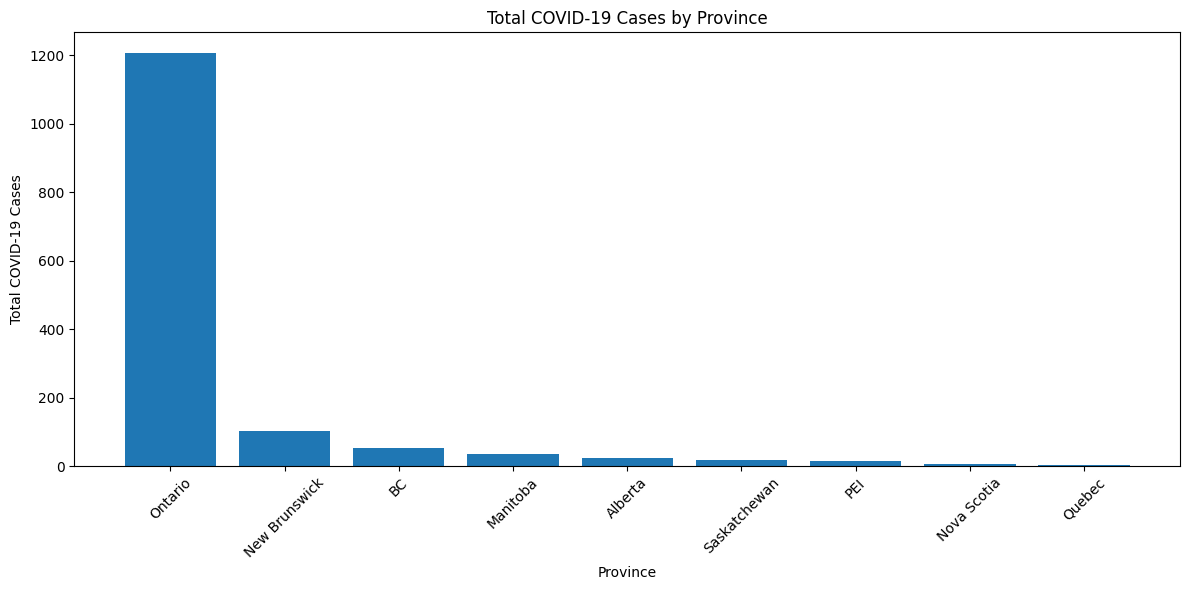

In [18]:
plt.figure(figsize=(12, 6))

plt.bar(
    province_cases["province"],
    province_cases["Total Cases"]
)

plt.xlabel("Province")
plt.ylabel("Total COVID-19 Cases")
plt.title("Total COVID-19 Cases by Province")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
#iii.)
highest_province = province_cases.iloc[0]["province"]

print("Province with highest cases:", highest_province)

Province with highest cases: Ontario


In [20]:
highest_province_data = data[
    data["province"] == highest_province
]

In [21]:
age_gender = (
    highest_province_data[
        highest_province_data["sex"].isin(["Male", "Female"])
    ]
    .groupby(["age", "sex"])
    .size()
    .reset_index(name="Total Cases")
)

In [22]:
age_gender_pivot = age_gender.pivot(
    index="age",
    columns="sex",
    values="Total Cases"
).fillna(0)

In [23]:
display(age_gender_pivot)

sex,Female,Male
age,,
0-19,16,16
20-29,82,68
30-39,89,76
40-49,72,93
50-59,120,104
60-69,92,112
70-79,63,49
80-89,28,29
90-99,28,4


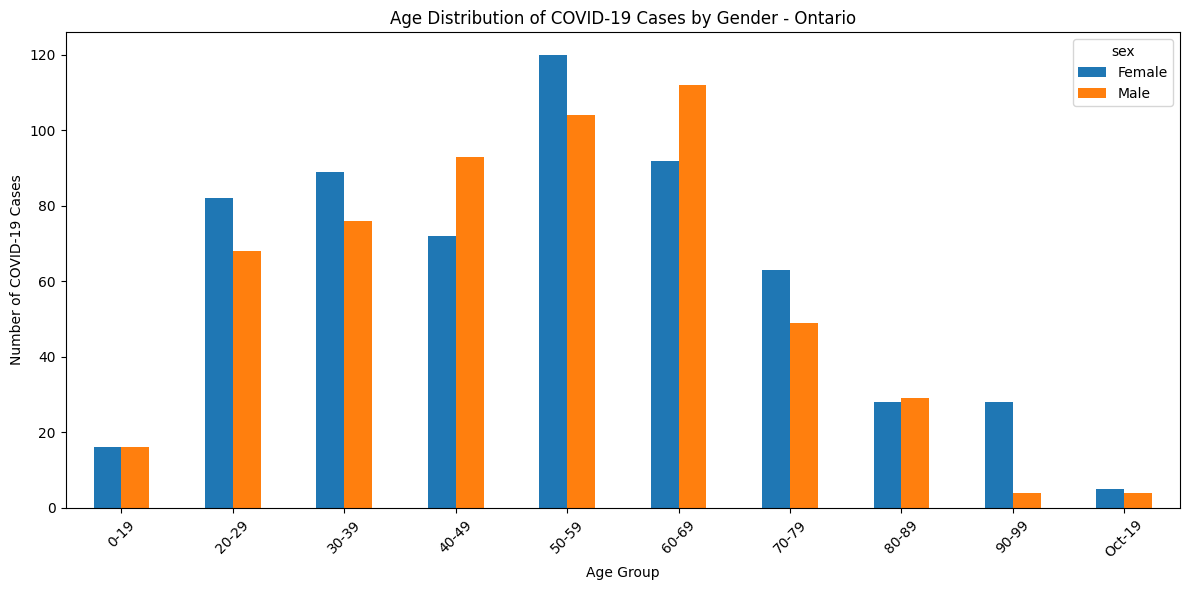

In [24]:
age_gender_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Age Group")
plt.ylabel("Number of COVID-19 Cases")
plt.title(
    f"Age Distribution of COVID-19 Cases by Gender - {highest_province}"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
#3.
#c.)
#i.)
def get_week_day(date):
    return date.strftime("%a")

In [26]:
print(get_week_day(pd.Timestamp("2020-01-25")))

Sat


In [27]:
data["report_week"] = data["date_report"].apply(get_week_day)

In [28]:
print(data[["date_report", "report_week"]].head(10))

  date_report report_week
0  2020-01-25         Sat
1  2020-01-27         Mon
2  2020-01-28         Tue
3  2020-01-31         Fri
4  2020-02-04         Tue
5  2020-02-06         Thu
6  2020-02-06         Thu
7  2020-02-14         Fri
8  2020-02-20         Thu
9  2020-02-23         Sun


In [29]:
#c.)
#ii.)
top_three_days = (
    data.groupby("report_week")
    .size()
    .reset_index(name="Total Cases")
    .sort_values("Total Cases", ascending=False)
    .head(3)
)

In [30]:
display(top_three_days)

,report_week,Total Cases
4,Thu,346
1,Mon,278
6,Wed,234


In [32]:
#c.)
#iii.)
data["Month"]

0       2020-01
1       2020-01
2       2020-01
3       2020-01
4       2020-02
         ...   
1456    2020-04
1457    2020-04
1458    2020-04
1459    2020-04
1460    2020-04
Name: Month, Length: 1461, dtype: object

In [33]:
monthly_gender = (
    data[
        data["sex"].isin(["Male", "Female"])
    ]
    .groupby(["Month", "sex"])
    .size()
    .reset_index(name="Total Cases")
)

In [34]:
monthly_gender_pivot = monthly_gender.pivot(
    index="Month",
    columns="sex",
    values="Total Cases"
).fillna(0)

In [35]:
display(monthly_gender_pivot)

sex,Female,Male
Month,,
2020-01,2,2
2020-02,10,6
2020-03,416,425
2020-04,247,192


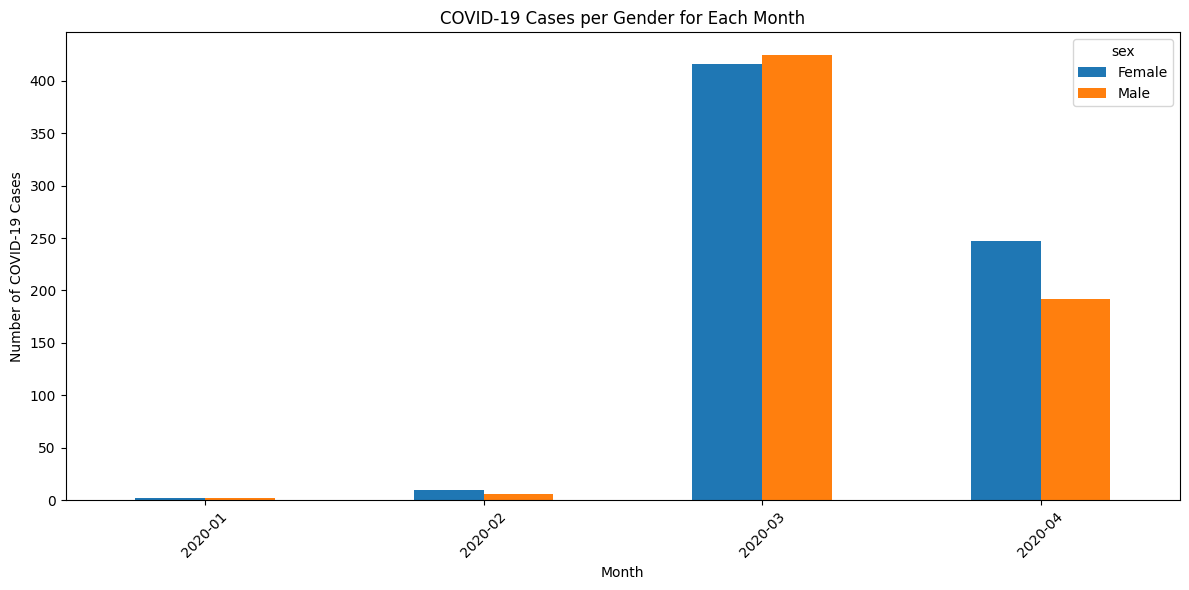

In [36]:
monthly_gender_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Month")
plt.ylabel("Number of COVID-19 Cases")
plt.title("COVID-19 Cases per Gender for Each Month")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()